In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")


✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# Updated dataset path
original_data_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"
base_split_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_full_split"
split_ratio = (0.7, 0.15, 0.15)  # Train, Val, Test
split_dirs = ['train', 'val', 'test']

# Create split directories if not exist
for split in split_dirs:
    os.makedirs(os.path.join(base_split_dir, split), exist_ok=True)

# Check if already split
already_split = all(
    os.path.exists(os.path.join(base_split_dir, split, class_name))
    for split in split_dirs
    for class_name in os.listdir(original_data_dir)
    if os.path.isdir(os.path.join(original_data_dir, class_name))
)

if not already_split:
    print("📂 Splitting full dataset into train, val, and test folders...")

    class_names = os.listdir(original_data_dir)
    for class_name in tqdm(class_names, desc="Splitting"):
        class_dir = os.path.join(original_data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        images = sorted(os.listdir(class_dir))
        images = [img for img in images if img.lower().endswith((".jpg", ".jpeg", ".png"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * split_ratio[0])
        n_val = int(n_total * split_ratio[1])

        split_paths = {
            'train': images[:n_train],
            'val': images[n_train:n_train + n_val],
            'test': images[n_train + n_val:]
        }

        for split in split_dirs:
            split_class_dir = os.path.join(base_split_dir, split, class_name)
            os.makedirs(split_class_dir, exist_ok=True)
            for img_name in split_paths[split]:
                src_path = os.path.join(class_dir, img_name)
                dst_path = os.path.join(split_class_dir, img_name)
                shutil.copy(src_path, dst_path)

    print("✅ Dataset split completed successfully.")
else:
    print("✅ Dataset already split. Skipping splitting.")


📂 Splitting full dataset into train, val, and test folders...


Splitting: 100%|██████████| 15/15 [18:24<00:00, 73.62s/it] 

✅ Dataset split completed successfully.


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# Parameters
img_size = (224, 224)
batch_size = 32
num_classes = 10
base_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_full_split"
epochs = 10  # ✅ Reduced from 30 to 10

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, "train"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, "val"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, "test"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Model setup
base_model = EfficientNetB0(include_top=False, input_shape=img_size + (3,), weights='imagenet')
base_model.trainable = False  # Frozen for feature extraction

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
checkpoint_path = "/content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5"
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.grid(True)
plt.show()


Found 19006 files belonging to 10 classes.
Found 4070 files belonging to 10 classes.
Found 4077 files belonging to 10 classes.
Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7683 - loss: 0.7858
Epoch 1: val_accuracy improved from -inf to 0.93514, saving model to /content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5


594/594 ━━━━━━━━━━━━━━━━━━━━ 1919s 3s/step - accuracy: 0.7685 - loss: 0.7853 - val_accuracy: 0.9351 - val_loss: 0.2168
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9262 - loss: 0.2340
Epoch 2: val_accuracy improved from 0.93514 to 0.94619, saving model to /content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5


594/594 ━━━━━━━━━━━━━━━━━━━━ 1875s 3s/step - accuracy: 0.9263 - loss: 0.2339 - val_accuracy: 0.9462 - val_loss: 0.1713
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9347 - loss: 0.1969
Epoch 3: val_accuracy improved from 0.94619 to 0.95184, saving model to /content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5


594/594 ━━━━━━━━━━━━━━━━━━━━ 1855s 3s/step - accuracy: 0.9347 - loss: 0.1969 - val_accuracy: 0.9518 - val_loss: 0.1514
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9399 - loss: 0.1798
Epoch 4: val_accuracy improved from 0.95184 to 0.95356, saving model to /content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5


594/594 ━━━━━━━━━━━━━━━━━━━━ 1816s 3s/step - accuracy: 0.9399 - loss: 0.1798 - val_accuracy: 0.9536 - val_loss: 0.1409
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9444 - loss: 0.1665
Epoch 5: val_accuracy improved from 0.95356 to 0.95504, saving model to /content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5


594/594 ━━━━━━━━━━━━━━━━━━━━ 1818s 3s/step - accuracy: 0.9444 - loss: 0.1665 - val_accuracy: 0.9550 - val_loss: 0.1358
Epoch 6/10
 13/594 ━━━━━━━━━━━━━━━━━━━━ 23:43 2s/step - accuracy: 0.9606 - loss: 0.1340

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Epoch 1 Training: 100%|██████████| 50/50 [09:10<00:00, 11.01s/it]


[Epoch 1] Train Acc: 0.2075, Val Acc: 0.4000


Epoch 2 Training: 100%|██████████| 50/50 [08:53<00:00, 10.68s/it]


...

[Epoch 8] Train Acc: 0.9175, Val Acc: 0.8800


Epoch 9 Training: 100%|██████████| 50/50 [08:46<00:00, 10.53s/it]


[Epoch 9] Train Acc: 0.9100, Val Acc: 0.8300


Epoch 10 Training: 100%|██████████| 50/50 [08:46<00:00, 10.53s/it]


[Epoch 10] Train Acc: 0.9200, Val Acc: 0.8900


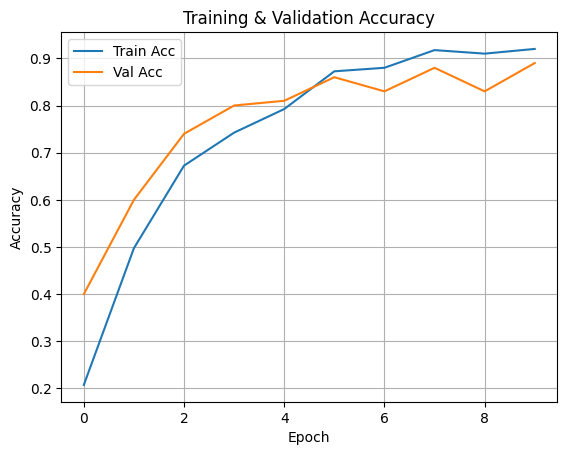

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch
import torch.nn as nn
from torch.optim import AdamW
from timm import create_model
from tqdm import tqdm
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
dataset_dir = '/content/EuroSAT_50'

# Transform
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Dataset
full_dataset = datasets.ImageFolder(dataset_dir, transform=transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Model
model = create_model('efficientnet_b4', pretrained=True, num_classes=10)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Training Loop
num_epochs = 10
train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / len(train_dataset)
    train_acc_history.append(train_acc)

    # Validation
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc = val_correct / len(val_dataset)
    val_acc_history.append(val_acc)

    print(f"[Epoch {epoch+1}] Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

# Plot accuracy
plt.plot(train_acc_history, label='Train Acc')
plt.plot(val_acc_history, label='Val Acc')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np


In [ ]:
# Evaluate on validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
classes = full_dataset.classes  # Get class names from ImageFolder

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()
